**Example demonstration of the scalar vortex coronagraph (SVC) optic from `poppy_utils/optics.py`.**

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'image.origin' : 'lower',
})
import numpy as np

First, let's visualize the 2D vortex mask. There are three main kinds: classic, sawtooth, and cosine. 

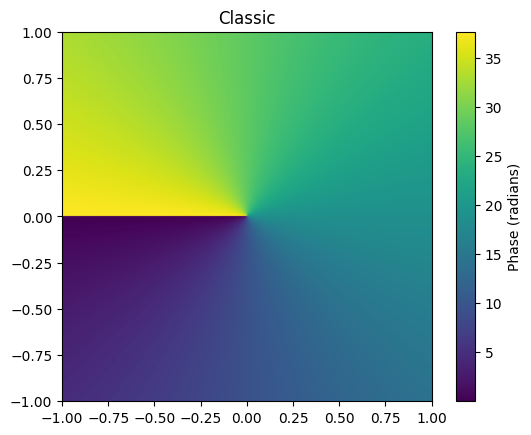

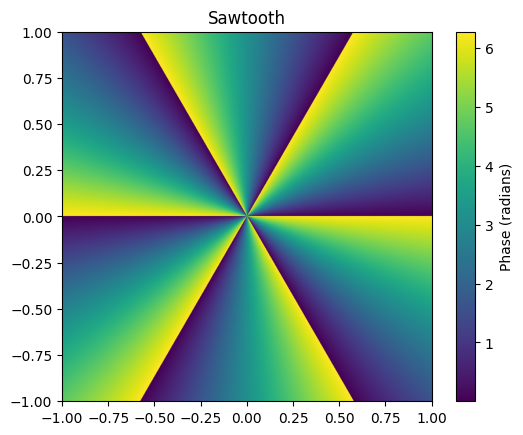

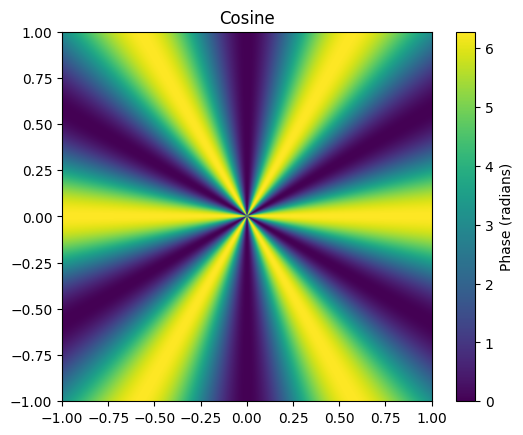

In [3]:
charge = 6
wavelength = 1
x, y = np.meshgrid(np.linspace(-1, 1, 1000), np.linspace(-1, 1, 1000))
azimuthal_angle = np.arctan2(y, x) # (radians)

# Define the 2D phase function
classic_phase = (azimuthal_angle + np.pi) * charge # smoothly increasing phase ramp, from zero to 2pi*charge
sawtooth_phase = np.mod(charge * azimuthal_angle, 2 * np.pi) # sawtooth phase ramp, from zero to 2pi
phasor = np.exp(1j * charge * azimuthal_angle)
cosine_phase = (np.real(phasor) + 1) * np.pi # from 0 to 2pi

plt.figure()
plt.imshow(classic_phase, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='Phase (radians)')
plt.title('Classic')

plt.figure()
plt.imshow(sawtooth_phase, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='Phase (radians)')
plt.title('Sawtooth')

plt.figure()
plt.imshow(cosine_phase, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='Phase (radians)')
plt.title('Cosine')
plt.show()

We can also simulate a Roddier dimple, an additional $\pi$ phase shift added to the central region of the vortex. The size of the dimple is specified by its radius in $\frac{\lambda}{D}$. The effect of the dimple is to improve broadband performance by creating destructive interference between the core and outer regions of the point spread function. 

0.206265


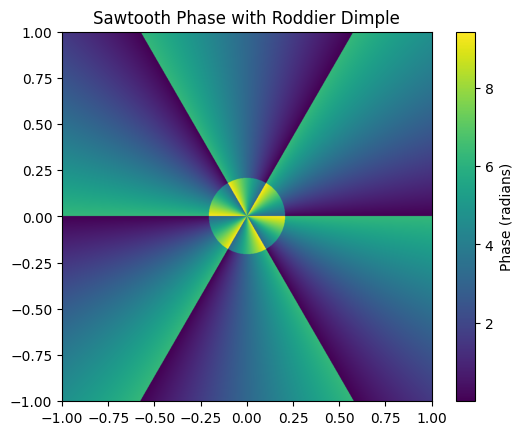

In [4]:
dimple_radius_coef = 0.5 # lambda/D
D = 1 # m
wavelength = 2e-6 # m
# Convert dimple coefficient in lambda/D to angular size in arcseconds
dimple_radius_arcsec = dimple_radius_coef * (wavelength / D) * (206265) # arcseconds
print(dimple_radius_arcsec)
r = np.sqrt(x**2 + y**2) # angular focal plane coordinates (arcsec)
dimple_phase = sawtooth_phase.copy()
dimple_phase[r < dimple_radius_arcsec] += np.pi

plt.figure()
plt.imshow(dimple_phase, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower')
plt.colorbar(label='Phase (radians)')
plt.title('Sawtooth Phase with Roddier Dimple')
plt.show()

**To convert dimple sizes between units of angle and length, use the following formulas:**
$$\text{Angular Size [radians]} = \frac{\text{Physical Size [m]}}{f_\# * D_{EP}} = \frac{C*\lambda_{0}}{D_{EP}}$$
$$\text{Angular Coefficient: C} = \frac{\text{Physical Size [m]}}{\lambda_{0} * f_\#}$$

When used at the design wavelength, there should be no difference in performance between a sawtooth and classic etch pattern. However, when we move to other wavelengths, the light will see a different relative phase depending on the specific etch. Note that this model does not take into account dispersion (wavelength dependent refractive index); we are only considering the fixed optical path difference for a given thickenss of material. 

Shown below is the relative phase experienced by light at 700 nm passing through a SVC designed for 600 nm. 

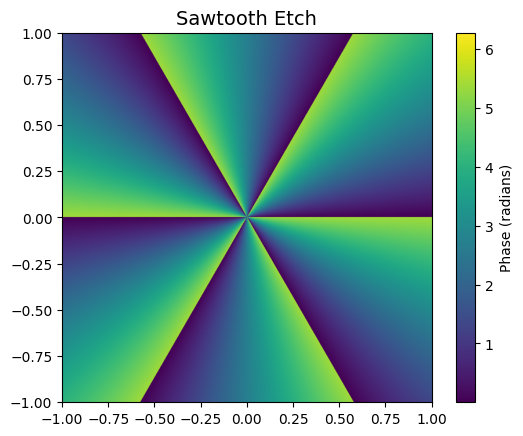

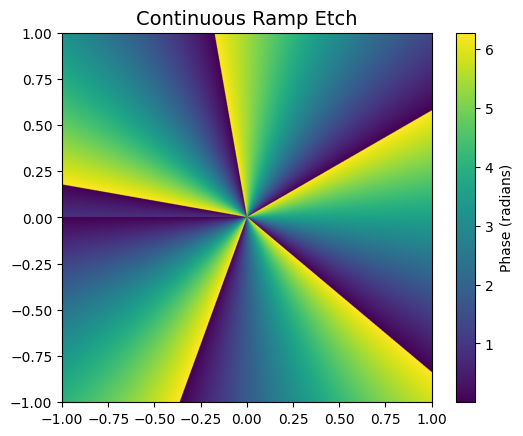

In [5]:
design_wl = 600e-9 # this defines the physical thickness of the mask, the wavelength it was designed for (nm)
testing_wl = 700e-9 # this is the wavelength that we pass through the mask in an experiment (nm)

# The OPD imparted by the glass will be fixed and determined by the design wavelength
# The phase of the light at the design wavelength will be a perfect vortex, but light off-band will be different
sawtooth_phase_rel = np.mod(sawtooth_phase * design_wl / testing_wl, 2 * np.pi)
classic_phase_rel = np.mod(classic_phase * design_wl / testing_wl, 2 * np.pi)

plt.figure() 
plt.imshow(sawtooth_phase_rel, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower', vmax=2*np.pi)
plt.colorbar(label='Phase (radians)')
plt.title('Sawtooth Etch', fontsize=14)

plt.figure()
plt.imshow(classic_phase_rel, extent=(-1, 1, -1, 1), cmap='viridis', origin='lower', vmax=2*np.pi)
plt.colorbar(label='Phase (radians)')
plt.title('Continuous Ramp Etch', fontsize=14)
plt.show()